# Partition Cell Types for UMAP plotting

To ensure that our cell type labels are as accurate as possible, we'll subset our dataset based on our `AIFI_L3` labels for review.

After performing leiden clusters, plot umaps and rank genes

Map previously labelled doublet cells to UMAP embeddings to annotate new doublet cell clusters 

Perform intermediate analysis like reparamaterization cell embeddings in particular cell types where doublet annotation is ambiguous 

## Load libraries

In [1]:
%config Completer.use_jedi = False

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

import concurrent.futures
from concurrent.futures import ThreadPoolExecutor
from datetime import date
import hisepy
import os
import pandas as pd
import re
import scanpy as sc
import scanpy.external as sce
import glob
import math
import matplotlib.pyplot as plt
import seaborn as sns
import quilter # best to put this after your matplotlib import
from PIL import Image
from PIL import ImageDraw

In [2]:
out_dir = 'output'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)

## Helper functions

In [3]:
def cache_uuid_path(uuid):
    cache_path = '/home/jupyter/cache/{u}'.format(u = uuid)
    if not os.path.isdir(cache_path):
        hise_res = hisepy.reader.cache_files([uuid])
    filename = os.listdir(cache_path)[0]
    cache_file = '{p}/{f}'.format(p = cache_path, f = filename)
    return cache_file

In [4]:
def read_parquet_uuid(uuid):
    cache_file = cache_uuid_path(uuid)
    res = pd.read_parquet(cache_file)
    return res

In [5]:
def sort_adata_uuid(uuid, sort_cols = ['AIFI_L2', 'sample.sampleKitGuid']):
    cache_file = cache_uuid_path(uuid)
    adata = sc.read_h5ad(cache_file)
    obs = adata.obs
    obs = obs.sort_values(sort_cols)
    adata = adata[obs.index]
    adata.write_h5ad(cache_file)

This function will enable us to connect to our .h5ad files without loading the entire thing into memory. We'll then load only the cells that we want for each cell class to assemble them for writing. This should save us some overhead as we do our subsetting.

In [6]:
def read_adata_backed_uuid(uuid):
    cache_file = cache_uuid_path(uuid)
    res = sc.read_h5ad(cache_file, backed = 'r')
    return res

This function will remove Ig-related genes, which is recommended by Marla Glass for analysis of B cell subtypes

In [7]:
def remove_ig_genes(adata):
    igl_genes = [gene for gene in adata.var_names if gene.startswith("IGL")]
    igk_genes = [gene for gene in adata.var_names if gene.startswith("IGK")]
    ighc_genes = [gene for gene in adata.var_names if gene.startswith("IGH")]
    exl_genes = igl_genes + igk_genes + ighc_genes

    filtered_genes = [gene for gene in adata.var_names if gene not in exl_genes]
    adata = adata[:, filtered_genes]

    return adata

In [8]:
def read_anndata_files(file_tuples):
    """
    Read Anndata objects from H5AD files and store them in a dictionary with custom names.

    Parameters:
        file_tuples (list of tuples): List of tuples where each tuple contains filename and desired name.

    Returns:
        dict: Dictionary containing Anndata objects with custom names.
    """
    anndata_dict = {}
    for filename, name in file_tuples:
        anndata_obj = anndata.read_h5ad(filename)
        anndata_dict[name] = anndata_obj
    return anndata_dict

In [9]:
def format_cell_type(cell_type):
    cell_type = re.sub('\\+', 'pos', cell_type)
    cell_type = re.sub('-', 'neg', cell_type)
    cell_type = re.sub(' ', '_', cell_type)
    return cell_type

In [10]:
def reformat_cell_type(cell_type):
    '''convert cell type names read in from file back to original L3 labels'''
    cell_type = re.sub('pos', '+', cell_type)
    cell_type = re.sub('neg', '-', cell_type)
    cell_type = re.sub('_',' ', cell_type)
    return cell_type

In [11]:
def element_id(n = 3):
    import periodictable
    from random import randrange
    rand_el = []
    for i in range(n):
        el = randrange(0,118)
        rand_el.append(periodictable.elements[el].name)
    rand_str = '-'.join(rand_el)
    return rand_str

In [12]:
# make a function to find files
def get_filepaths_with_glob(root_path: str, file_regex: str):
    return glob.glob(os.path.join(root_path, file_regex))

In [13]:
# Define a function to extract the desired substring using regex
def extract_substring(path):
    pattern = r'up1_cluster_harmonize_(.*?)_\d{4}-\d{2}-\d{2}\.h5ad'
    match = re.search(pattern, path)
    if match:
        return match.group(1)
    return None


In [14]:
def plot_rank_genes(adata):
    df = sc.get.rank_genes_groups_df(adata, group=None)
    df = df.groupby('group').head(20).reset_index(drop=True)
    groups = df.groupby('group')
    df

    n_groups = len(groups)
    n_cols = 10
    n_rows = math.ceil(n_groups / n_cols)
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
    fig.suptitle(adata.obs['AIFI_L3'][0], fontsize=50)
    
    if n_rows == 1:
        axs = axs.reshape(1, -1)
    
    for ax in axs.flat:
        ax.set_visible(False)
    
    for i, (name, group) in enumerate(groups):
        row, col = divmod(i, n_cols)
        ax = axs[row, col]
        ax.set_visible(True)
        ax.scatter(group['scores'], group['names'])
        ax.invert_yaxis()
        ax.set_title(str(name) + " vs Rest")
        ax.set_xlabel('T-Statistics')
        ax.set_ylabel('Gene')
    
    plt.tight_layout()
    return(plt)


## Read in data

In [15]:
output_path = "./output/"

In [16]:
### read in processed leiden adata
filenames = get_filepaths_with_glob(output_path, "up1_cluster_harmonize_*.h5ad")  

In [17]:
### extract cell types
# Apply the function to each filename in the list using list comprehension
cell_types = [extract_substring(path) for path in filenames]

# Print the result


In [18]:
## reformat cell types
cell_types2 = [reformat_cell_type(cell_type) for cell_type in cell_types]
cell_types2[:5]

['Naive Vd1 gdT',
 'Activated memory B cell',
 'BaEoMaP cell',
 'Proliferating T cell',
 'GZMB- CD27+ EM CD4 T cell']

In [19]:
file_dict = dict(zip(cell_types, filenames))

In [20]:
list(file_dict.items())[:20]

[('Naive_Vd1_gdT',
  './output/up1_cluster_harmonize_Naive_Vd1_gdT_2024-08-22.h5ad'),
 ('Activated_memory_B_cell',
  './output/up1_cluster_harmonize_Activated_memory_B_cell_2024-08-22.h5ad'),
 ('BaEoMaP_cell',
  './output/up1_cluster_harmonize_BaEoMaP_cell_2024-08-21.h5ad'),
 ('Proliferating_T_cell',
  './output/up1_cluster_harmonize_Proliferating_T_cell_2024-08-22.h5ad'),
 ('GZMBneg_CD27pos_EM_CD4_T_cell',
  './output/up1_cluster_harmonize_GZMBneg_CD27pos_EM_CD4_T_cell_2024-08-22.h5ad'),
 ('Intermediate_monocyte',
  './output/up1_cluster_harmonize_Intermediate_monocyte_2024-08-23.h5ad'),
 ('Core_naive_CD4_T_cell',
  './output/up1_cluster_harmonize_Core_naive_CD4_T_cell_2024-08-22.h5ad'),
 ('GZMBneg_CD27neg_EM_CD4_T_cell',
  './output/up1_cluster_harmonize_GZMBneg_CD27neg_EM_CD4_T_cell_2024-08-22.h5ad'),
 ('Core_CD14_monocyte',
  './output/up1_cluster_harmonize_Core_CD14_monocyte_2024-08-21.h5ad'),
 ('ISGpos_naive_CD4_T_cell',
  './output/up1_cluster_harmonize_ISGpos_naive_CD4_T_cell_2

In [21]:
# Given list of cell types to redo umap neighbors and PCs
cell_types = ['Core_CD14_monocyte','CM_CD4_T_cell','KLRF1pos_GZMBpos_CD27neg_EM_CD8_T_cell']

In [22]:
 # Subset the dictionary based on keys in cell_types list
subfile_dict = {key: file_dict[key] for key in cell_types if key in file_dict}
subfile_dict

{'Core_CD14_monocyte': './output/up1_cluster_harmonize_Core_CD14_monocyte_2024-08-21.h5ad',
 'CM_CD4_T_cell': './output/up1_cluster_harmonize_CM_CD4_T_cell_2024-08-21.h5ad',
 'KLRF1pos_GZMBpos_CD27neg_EM_CD8_T_cell': './output/up1_cluster_harmonize_KLRF1pos_GZMBpos_CD27neg_EM_CD8_T_cell_2024-08-22.h5ad'}

In [25]:
### read in doublet metadata from 141 scRNA seq run

doublet_meta = pd.read_csv("up1_scrublet_results_2024-08-16.csv", index_col=0)
doublet_meta['doublets_manual'] = 'no'
#doublet_meta.set_index('barcodes')
#if 'barcodes' in doublet_meta.columns:
 #   doublet_meta = doublet_meta.rename(columns={'barcodes': 'barcodes_col'})
# Reset the index to make 'barcodes' a column
#doublet_meta = doublet_meta.reset_index()
doublet_meta.head()

,barcodes,predicted_doublet,doublet_score,doublets_manual
0,b9993ec4872b11ebb599de5a8c2059ae,False,0.060170,no
1,b99942fc872b11ebb599de5a8c2059ae,False,0.013071,no
2,b9996f66872b11ebb599de5a8c2059ae,False,0.120700,no
3,b99971c8872b11ebb599de5a8c2059ae,False,0.018831,no
4,b9997290872b11ebb599de5a8c2059ae,False,0.026079,no


In [26]:
# Create an empty dictionary
adata_celltypes = {}

In [28]:
for label, file in subfile_dict.items():
    print("Key:", label)
    print("Value:", file)

    adata = sc.read_h5ad(file)
    #print(adata)

    meta = adata.obs

    # Check for conflict and drop the index if a column has the same name
    if 'barcodes' in meta.index.names and 'barcodes' in meta.columns:
        meta = meta.reset_index(drop=True)
    #meta.head()

    # Perform the merge
    meta2 = pd.merge(meta, doublet_meta, how='left', on=['barcodes', 'predicted_doublet','doublet_score'])#'sample.sampleKitGuid', 'subject.subjectGuid', 'subject.biologicalSex'])
    
    # Print the result
    #print(meta2.head())
    
    # add back to adata
    adata.obs = meta2

    print(adata)

    crosstab_table = pd.crosstab(adata.obs['leiden_harmony_2'], adata.obs['doublets_manual'].fillna('NA'))



    print(crosstab_table) 

    adata_celltypes[label] = adata
    
    

Key: Core_CD14_monocyte
Value: ./output/up1_cluster_harmonize_Core_CD14_monocyte_2024-08-21.h5ad
AnnData object with n_obs × n_vars = 224790 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'specimens.specimenType', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_

In [76]:
adata_celltypes

{'Core_CD14_monocyte': AnnData object with n_obs × n_vars = 979131 × 33538
     obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_man

## Plot Harmonized Umaps

In [29]:
### create doublet cluster dict
doublet_clust = {'Core_CD14_monocyte':['16', '17','22'],
                'CM_CD4_T_cell':['0', '2', '11','15'],
                'KLRF1pos_GZMBpos_CD27neg_EM_CD8_T_cell':['19', '28', '29']}
doublet_clust

{'Core_CD14_monocyte': ['16', '17', '22'],
 'CM_CD4_T_cell': ['0', '2', '11', '15'],
 'KLRF1pos_GZMBpos_CD27neg_EM_CD8_T_cell': ['19', '28', '29']}

Key: Core_CD14_monocyte
Value: AnnData object with n_obs × n_vars = 224790 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'specimens.specimenType', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'double

/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Key: CM_CD4_T_cell
Value: AnnData object with n_obs × n_vars = 215598 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'specimens.specimenType', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_ma

/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Key: KLRF1pos_GZMBpos_CD27neg_EM_CD8_T_cell
Value: AnnData object with n_obs × n_vars = 13046 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'specimens.specimenType', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_

/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


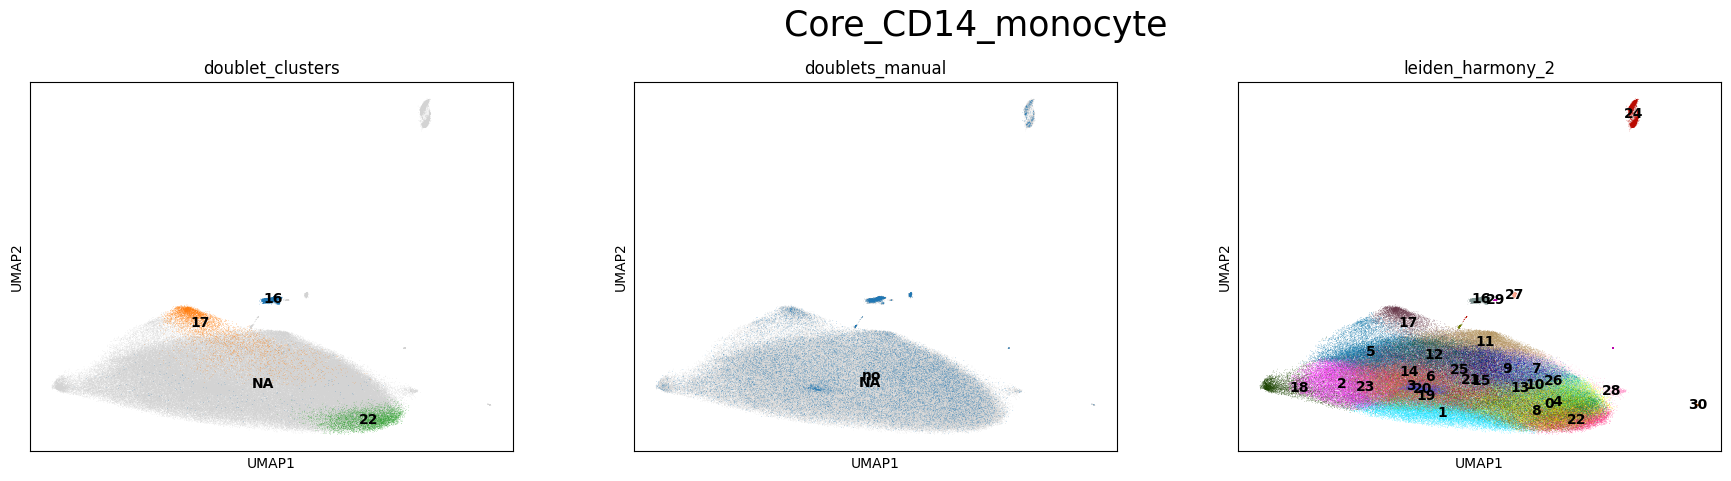

<Figure size 4200x3000 with 0 Axes>

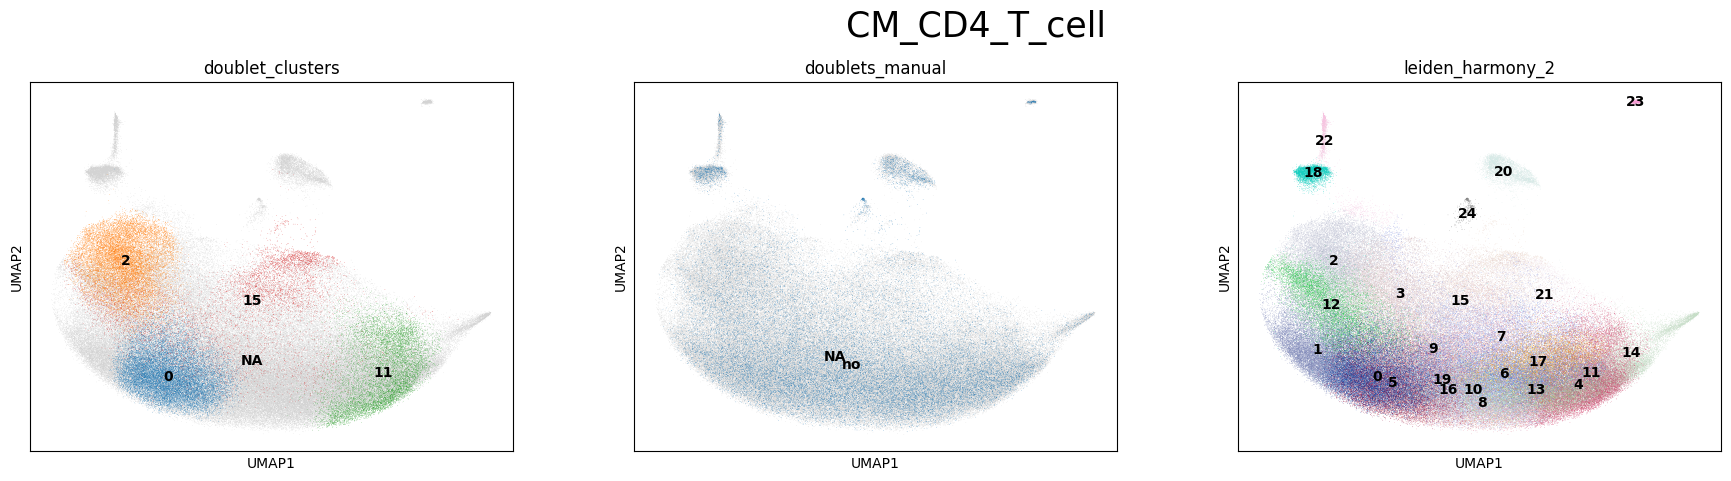

<Figure size 4200x3000 with 0 Axes>

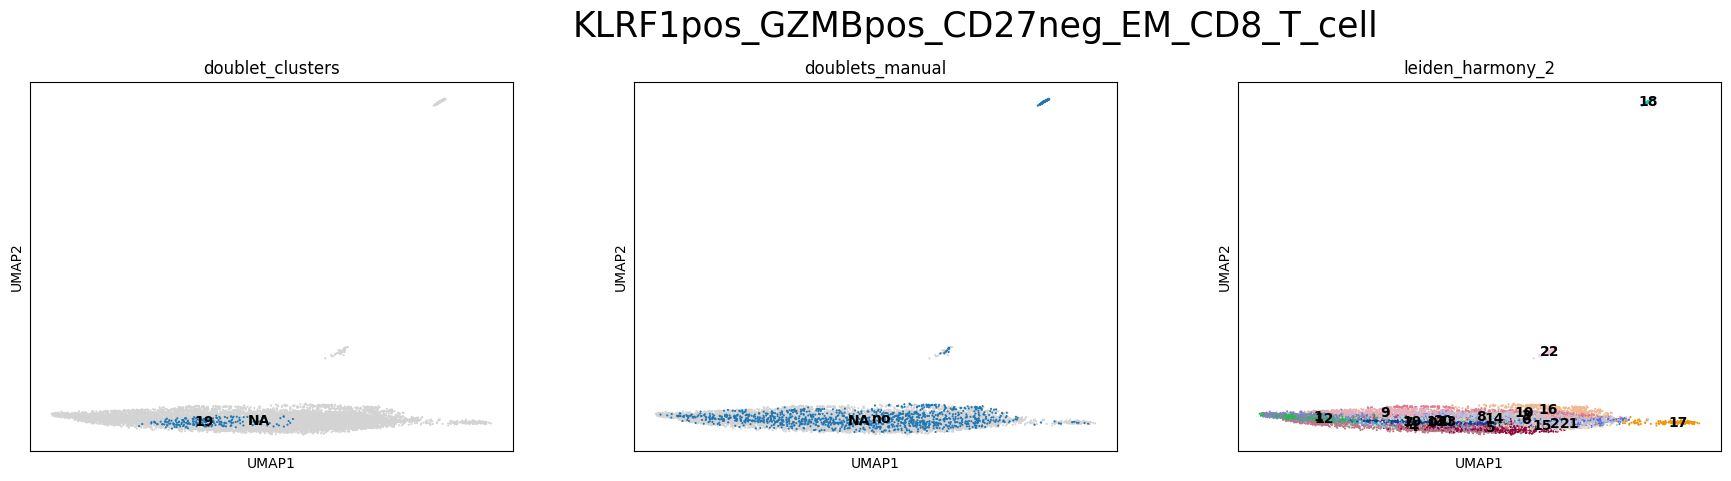

<Figure size 4200x3000 with 0 Axes>

In [31]:
for label, adata in adata_celltypes.items():
    print("Key:", label)
    print("Value:", adata)

    print(doublet_clust[label])

    # Convert the column to string type if it's not already
    adata.obs['leiden_harmony_2'] = adata.obs['leiden_harmony_2'].astype(str)
    # Create a new column in metadata called "doublet_clusters"
    adata.obs['doublet_clusters'] = [cluster if cluster in doublet_clust[label] else None for cluster in adata.obs['leiden_harmony_2']]
    print(pd.crosstab(adata.obs['doublet_clusters'], adata.obs['doublets_manual']))

    p1 = sc.pl.umap(adata, 
               color=['doublet_clusters', 'doublets_manual', 'leiden_harmony_2'],
               ncols=3, 
               #save='_UMAP_leiden.png',
               legend_loc='on data',return_fig = True)

    p1.suptitle(label, fontsize=25,y=1.05)

    plt.figure(figsize=(14, 10), dpi=300)

    p1.savefig('./figures/' + "doublet_clusters_" + label + "_.png")
    

## Restore/Plot Pre-harmonize UMAP

In [32]:
adata_celltypes

{'Core_CD14_monocyte': AnnData object with n_obs × n_vars = 224790 × 33538
     obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'specimens.specimenType', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manu

In [33]:
# Create an empty dictionary
preharm_adata_celltypes = adata_celltypes

In [34]:
preharm_adata_celltypes

{'Core_CD14_monocyte': AnnData object with n_obs × n_vars = 224790 × 33538
     obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'specimens.specimenType', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manu

In [37]:
preharm_adata_celltypes

{'Core_CD14_monocyte': AnnData object with n_obs × n_vars = 224790 × 33538
     obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'specimens.specimenType', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manu

In [ ]:
for label, adata in preharm_adata_celltypes.items():
    print("Key:", label)
    print("Value:", adata)

    # store harmonized umap into separate slot
    adata.obsm['X_umap_harmony'] = adata.obsm['X_umap']
    
    print('PCA', end = "; ")
    # Run PCA
    sc.tl.pca(adata, svd_solver = 'arpack')

    print('Neighbors', end = "; ")
    # Find nearest neighbors
    sc.pp.neighbors(
        adata, 
        n_neighbors = 50,
        n_pcs = 30
    )

    print('UMAP', end = "; ")
    # Run UMAP
    sc.tl.umap(adata, min_dist = 0.05, init_pos="X_pca")

    out_file = '/home/jupyter/data/up1_cluster_pre_harmonize_{c}_{d}.h5ad'.format(
        c = label,
        d = date.today()
    )
    adata.write_h5ad(out_file)

    # add back to dict
    preharm_adata_celltypes[label] = adata


In [83]:
preharm_adata_celltypes

{'Core_CD14_monocyte': AnnData object with n_obs × n_vars = 979131 × 33538
     obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_man

Current cell type: Core_CD14_monocyte
doublets_manual     no   yes
doublet_clusters            
16                1330  5238
17                 154  2620
22                 881   184
Current cell type: CM_CD4_T_cell
doublets_manual      no  yes
doublet_clusters            
0                 22040  126
2                 16648  146
11                12297  118
15                 6255  452
Current cell type: KLRF1pos_GZMBpos_CD27neg_EM_CD8_T_cell
doublets_manual    no  yes
doublet_clusters          
19                366  115
28                 11   66
29                 32   62


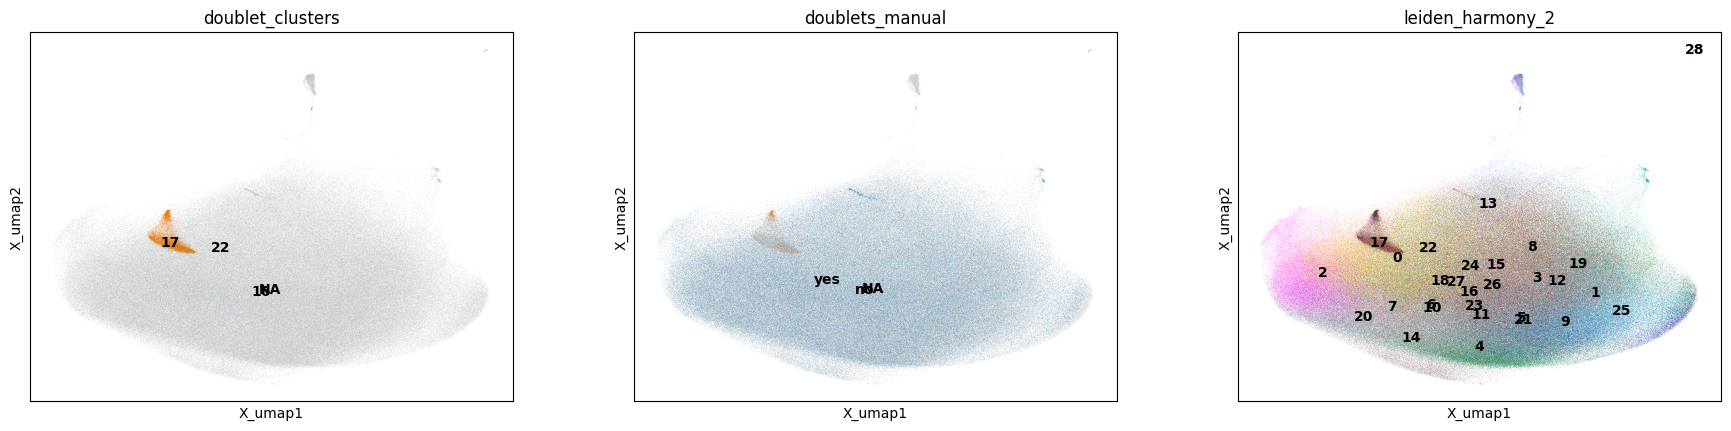

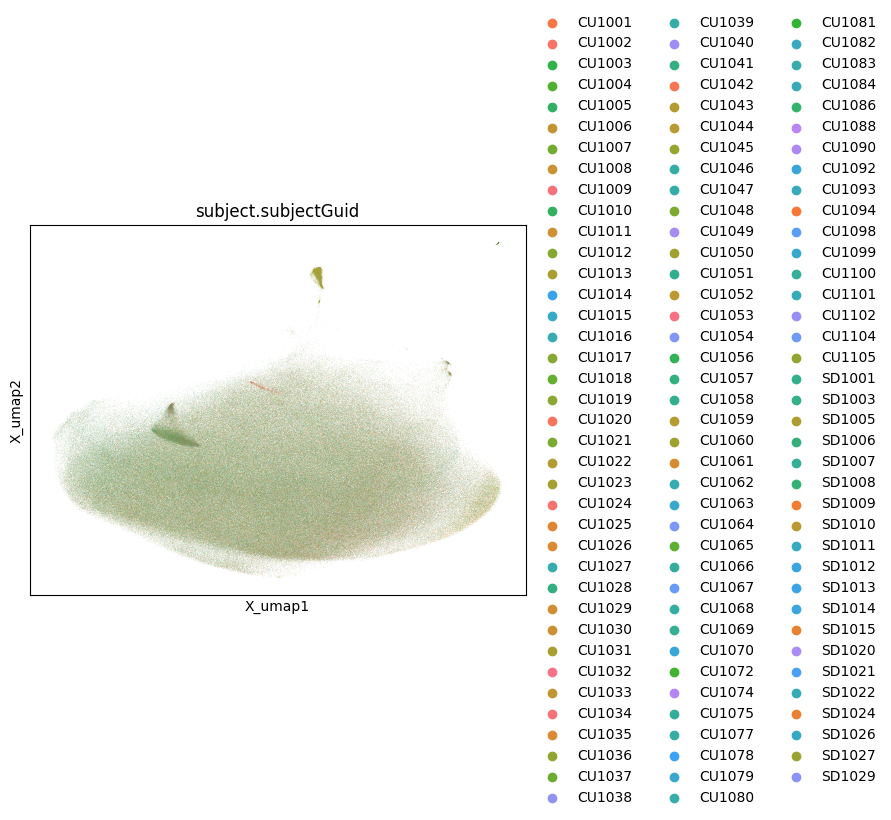

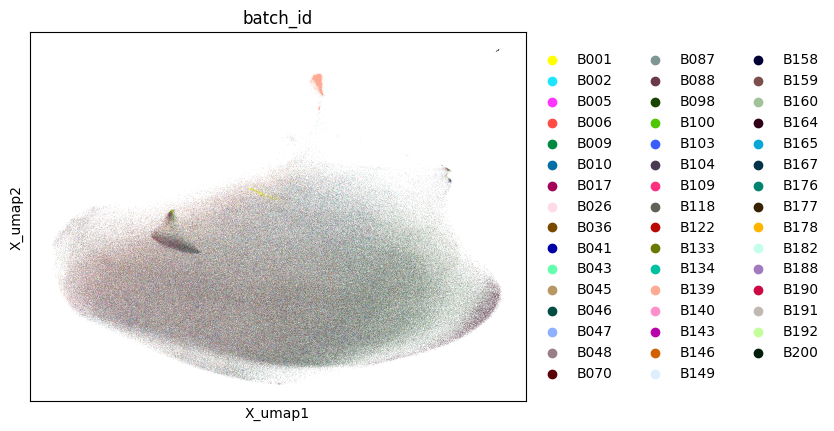

<Figure size 4200x3000 with 0 Axes>

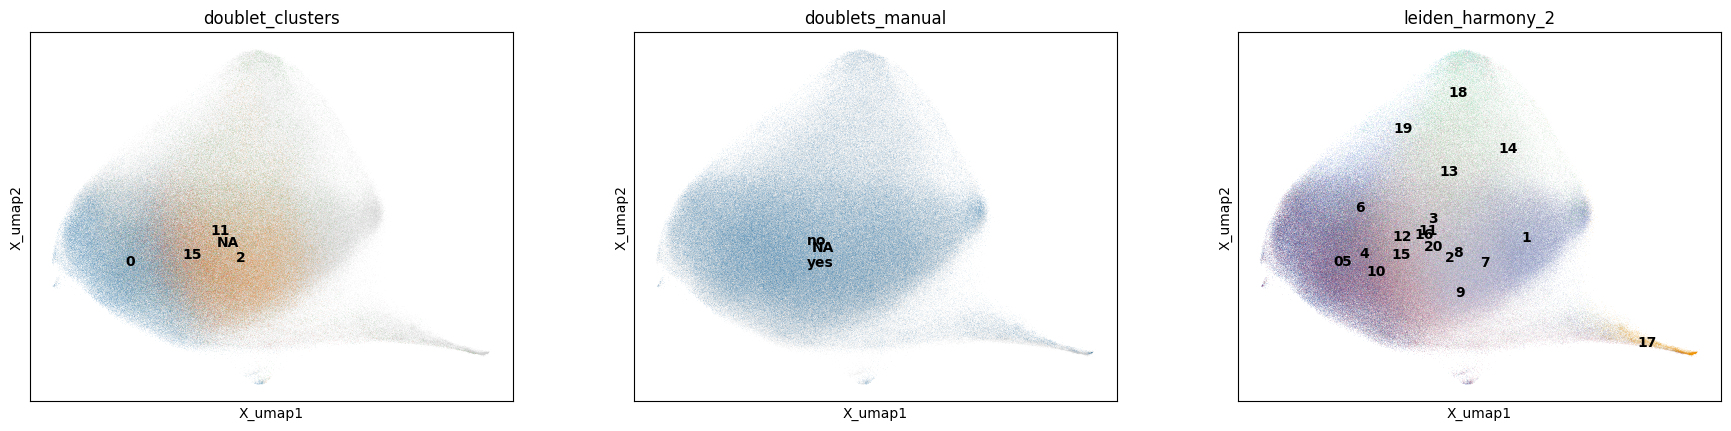

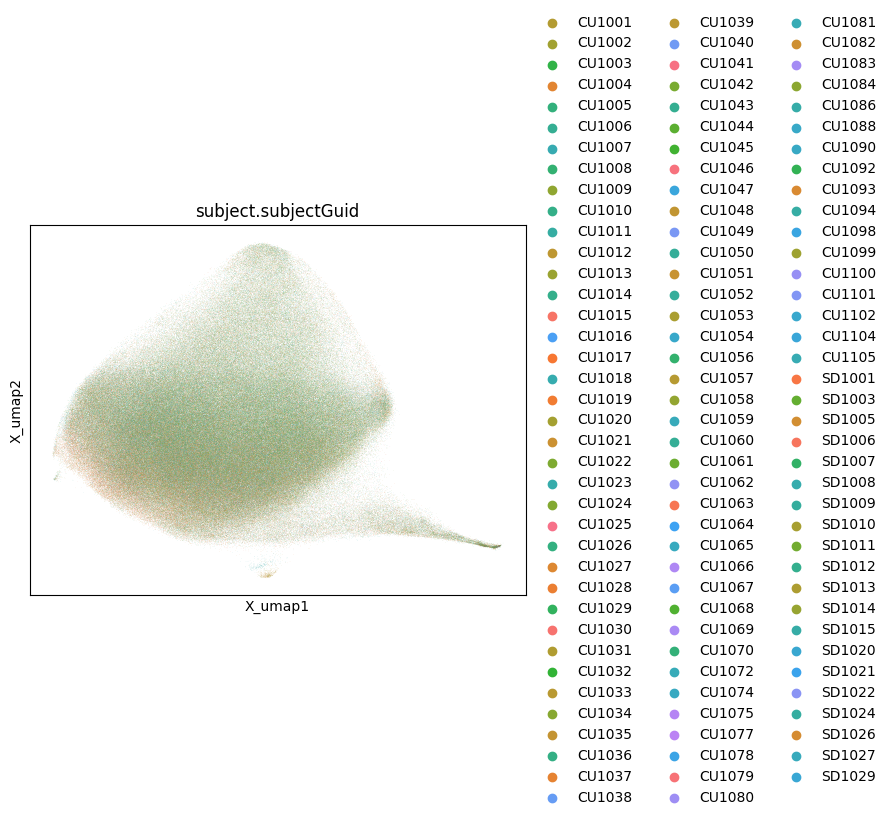

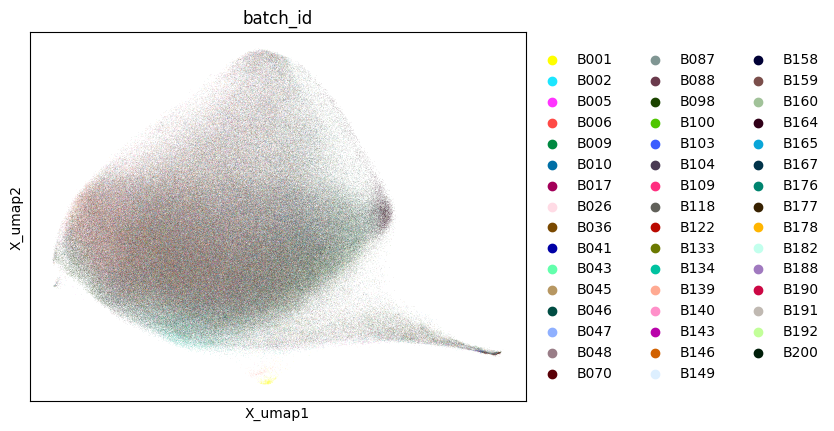

<Figure size 4200x3000 with 0 Axes>

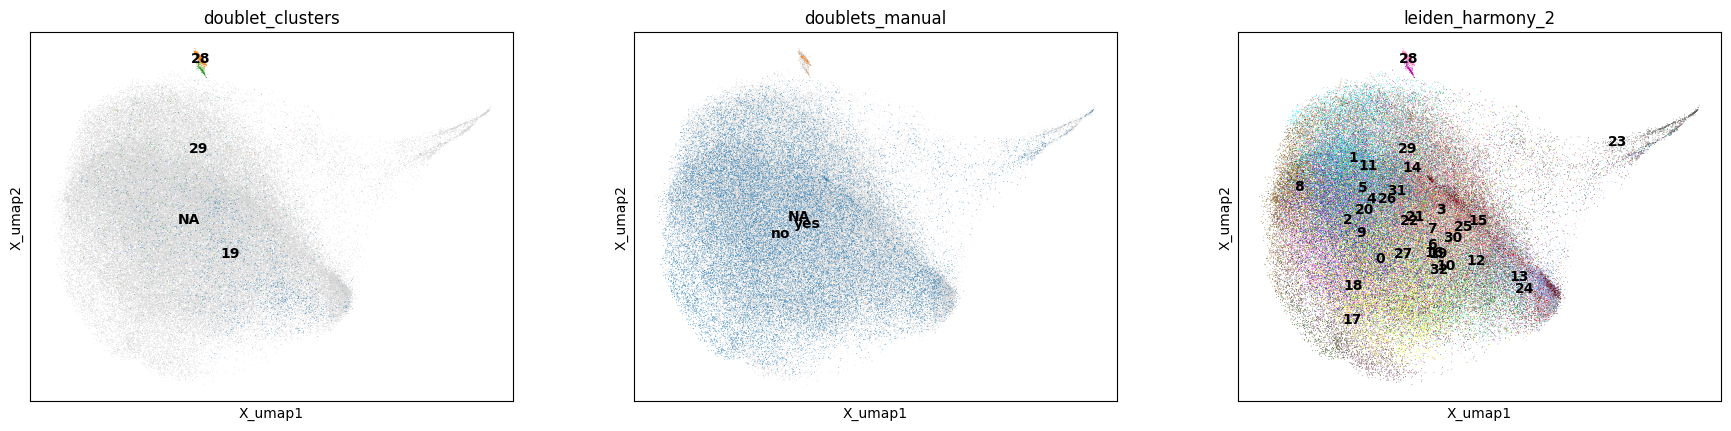

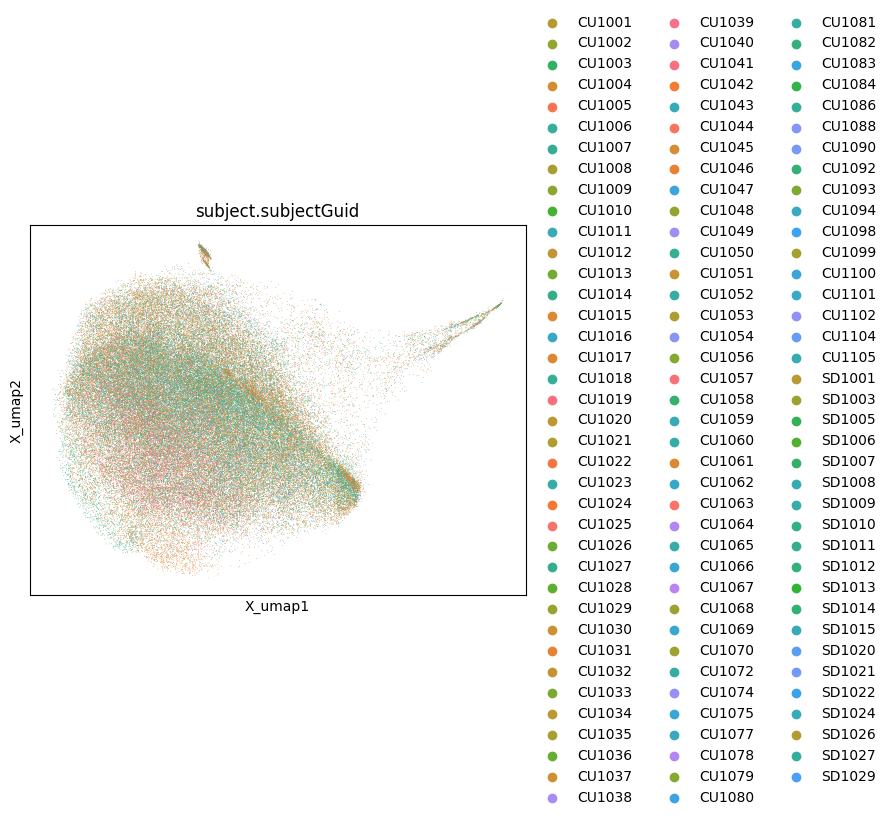

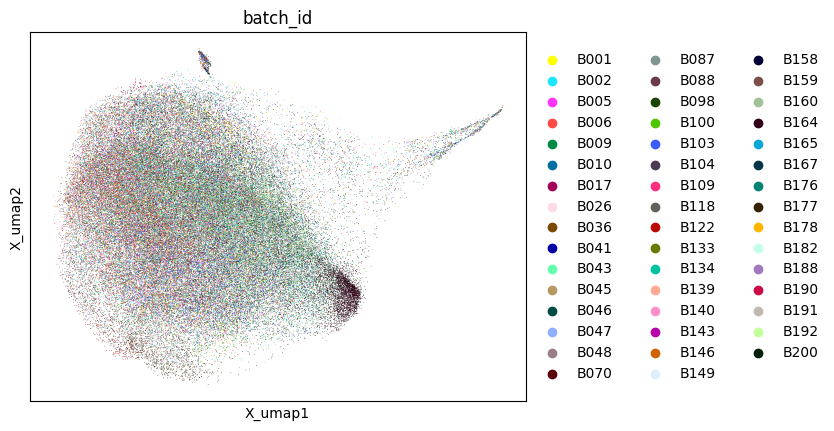

<Figure size 4200x3000 with 0 Axes>

In [111]:
grid = []
for label, adata in preharm_adata_celltypes.items():

    print("Current cell type: " + label)

    print(pd.crosstab(adata.obs['doublet_clusters'], adata.obs['doublets_manual']))
    
    p1 = sc.pl.embedding(adata, 
               color=['doublet_clusters', 'doublets_manual', 'leiden_harmony_2'],
               ncols=3, 
               #save='_UMAP_leiden.png',
               legend_loc='on data',return_fig = True, basis = 'X_umap')
    
    # Generate a large palette
    palette = sns.color_palette("husl", 144)  # Adjust the number to match your unique categories
    
    #palette =  plt.cm.get_cmap('hsv', 144)
    # Map this palette to your categories
    category_colors = dict(zip(adata.obs['subject.subjectGuid'].unique(), palette))
    
    p2 = sc.pl.embedding(adata, 
               color=['subject.subjectGuid'],
               ncols=3, 
               palette=category_colors,return_fig = True, basis = 'X_umap')
    
    
    p3 = sc.pl.embedding(adata, 
               color=['batch_id'],
               ncols=3, return_fig = True, basis = 'X_umap')
    
    p4 = p2 + p3
    
    p5 = p1 / p4
    
    p5.suptitle("Pre-harmonized " + label, fontsize=25,y=1.00)
    
    plt.figure(figsize=(14, 10), dpi=300)
    
    #p5.savefig('./figures/' + "doublet_clusters_pre_harm_" + label + "_.png")

    grid.append(p5)

In [108]:
#### Show grid plots

for i, fig in enumerate(grid):
    grid[i]  # This will display the figure in a GUI window
    #plt.pause(1)

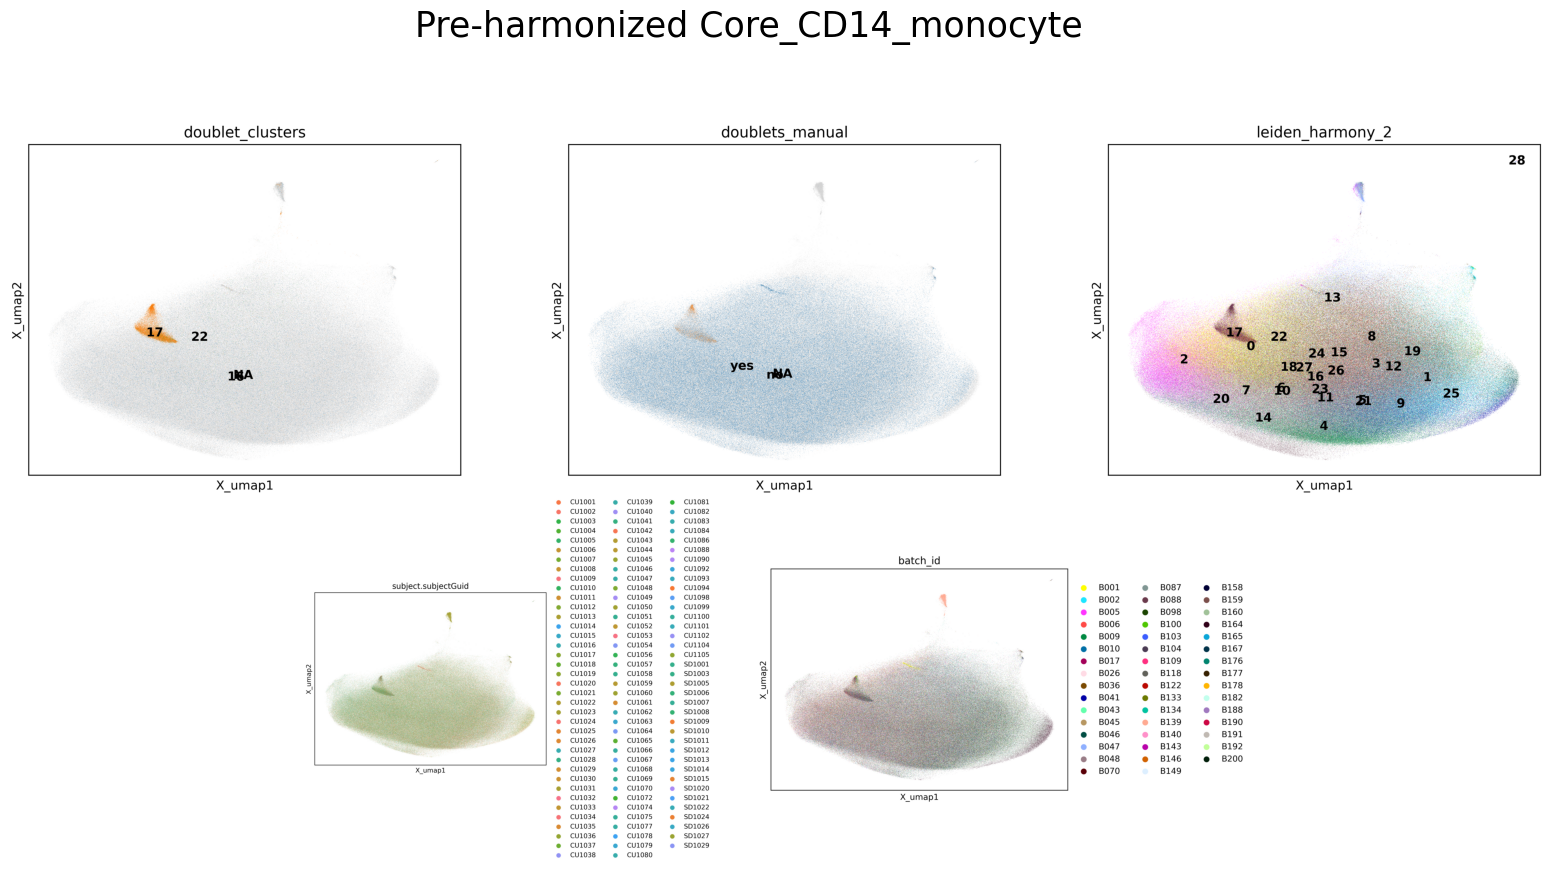

In [107]:
grid[0]

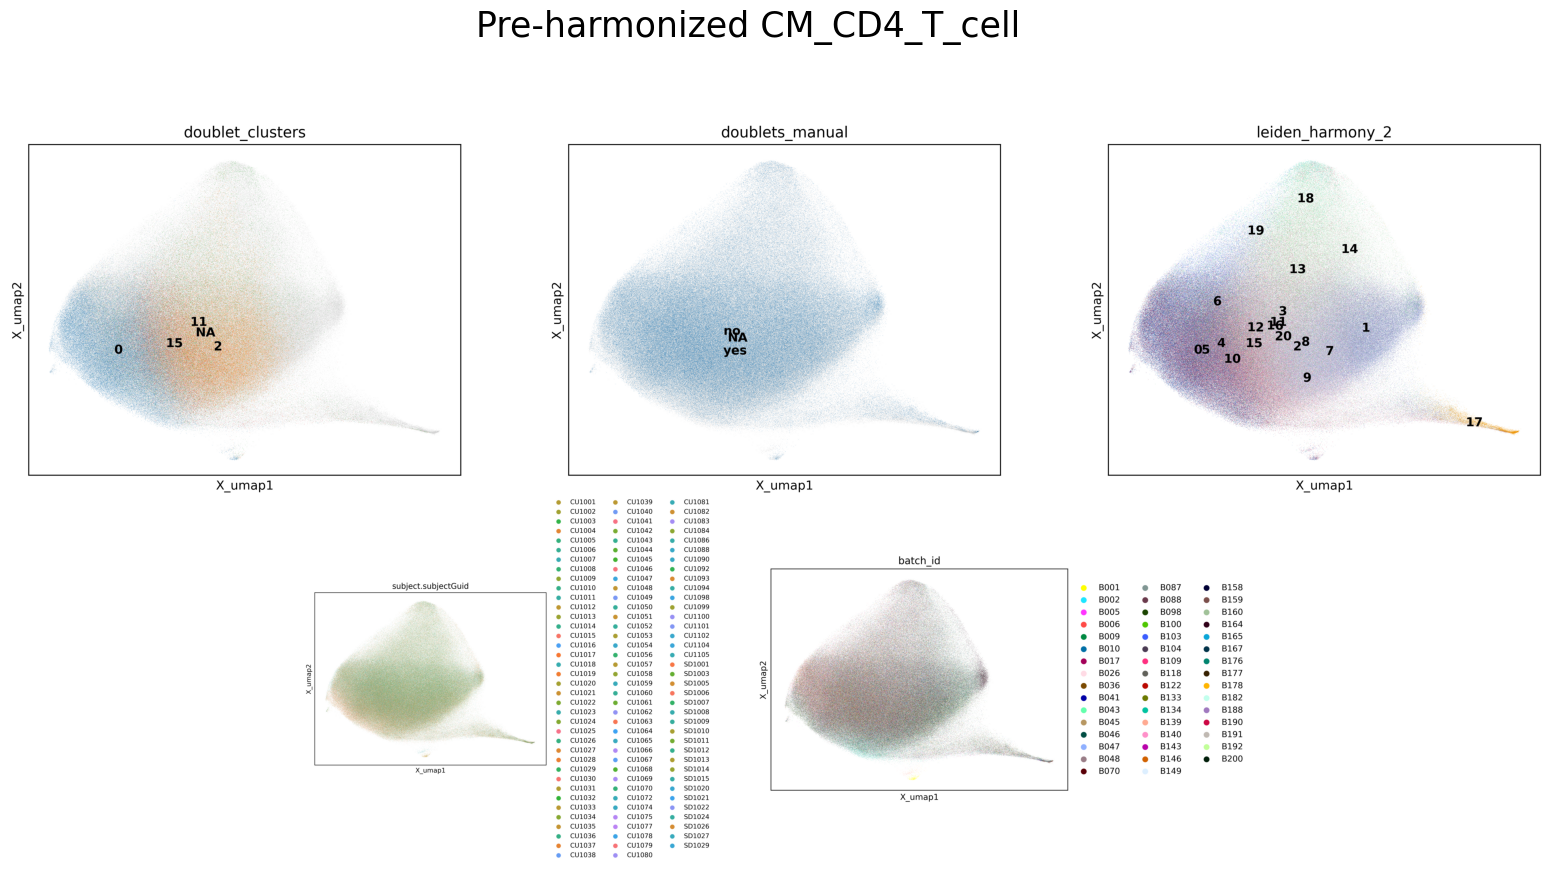

In [109]:
grid[1]

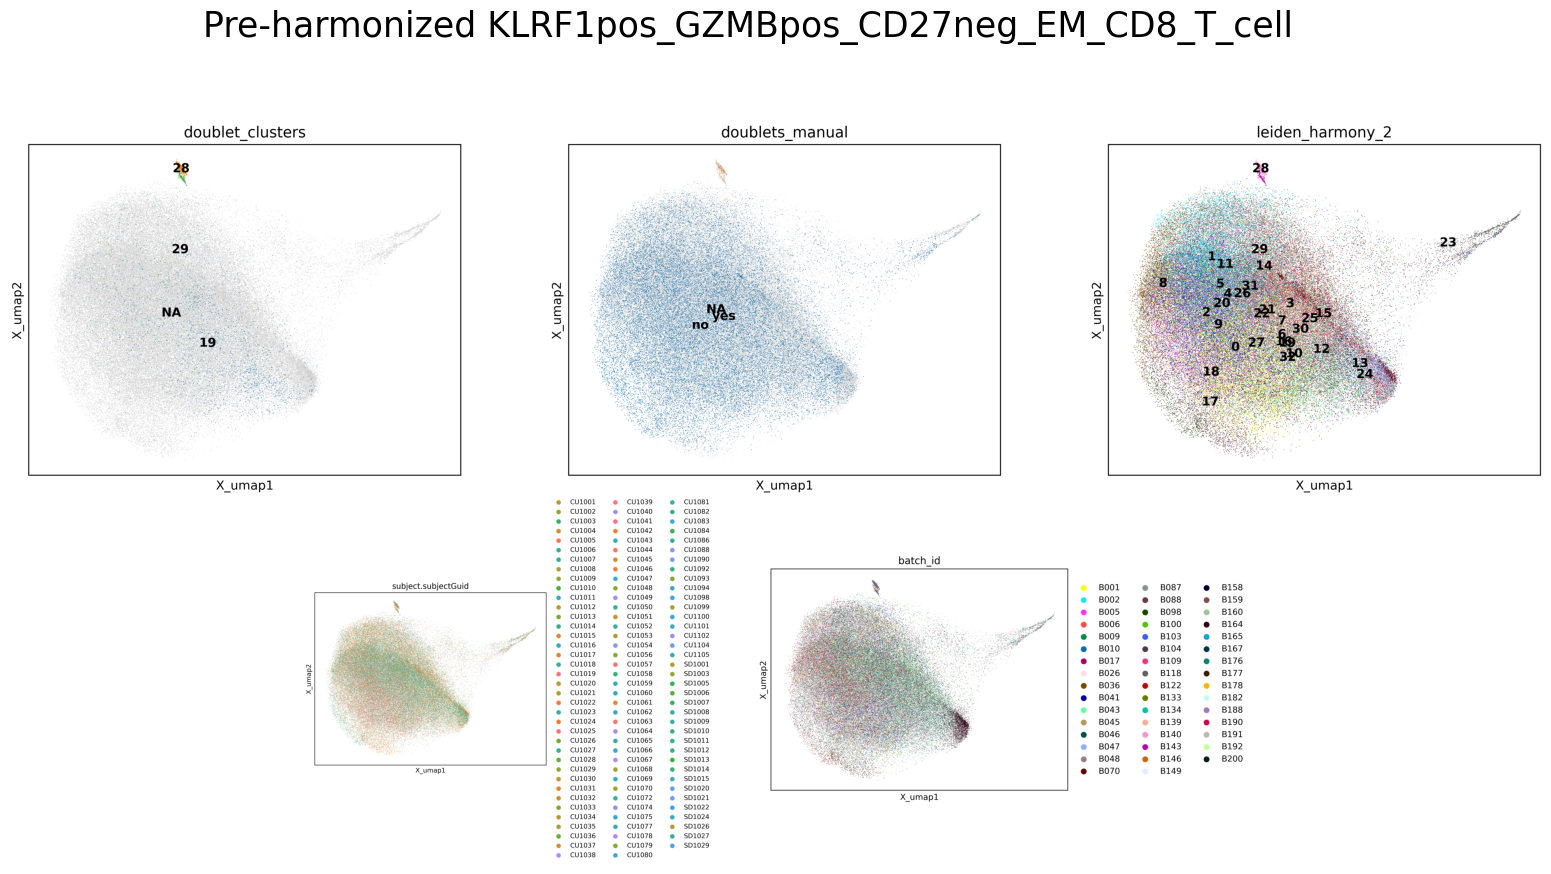

In [110]:
grid[2]